In [172]:
import os
import pickle
import numpy as np
import os.path as osp
from tqdm import tqdm
from pprint import pprint
from datetime import datetime
import matplotlib.pyplot as plt

import torch
import tensorflow as tf
from tensorflow.keras import losses
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import load_model


from src.models import CNNtf
import src.cf_methods.countergan.utils  as cutils
from src.cf_methods.countergan import create_convolutional_autoencoder

tf.experimental.numpy.experimental_enable_numpy_behavior()

plt.style.use('seaborn-v0_8-darkgrid')

In [173]:
from src.utils import seed_tf

seed_tf()

Loading MNIST data

In [174]:
def convert_multiclass_to_binary(x, y, initial_class, target_class, class_encoding):
    init_class_ind = tf.where(y==initial_class)
    target_class_ind = tf.where(y==target_class)

    y_bin = tf.concat([y[init_class_ind], y[target_class_ind]], axis=0)
    x_bin = tf.concat([x[init_class_ind], x[target_class_ind]], axis=0)

    y_bin_encoded = tf.where(y_bin==initial_class, 
                             class_encoding[initial_class], 
                             class_encoding[target_class])

    return x_bin, y_bin_encoded 

In [176]:
INIT_CLASS = 1
DESIRED_CLASS = 8  # This is the target class that the generator will learn to synthetize
N_CLASSES = 2

class_encodings = {INIT_CLASS: 0, DESIRED_CLASS: 1}
(x_train, y_train), (x_test, y_test) = mnist.load_data()

x_train = (x_train / 255.).astype("float32")
x_test = (x_test / 255.).astype("float32")

In [177]:
X_train, y_train = convert_multiclass_to_binary(x_train, y_train, INIT_CLASS, DESIRED_CLASS, class_encodings) 
X_test, y_test = convert_multiclass_to_binary(x_test, y_test, INIT_CLASS, DESIRED_CLASS, class_encodings)

X_train = tf.transpose(X_train, perm=(0, 2, 3, 1))
X_test = tf.transpose(X_test, perm=(0, 2, 3, 1))

y_train_encoded = to_categorical(y_train, N_CLASSES)
y_test_encoded = to_categorical(y_test, N_CLASSES)

## Train AE

In [ ]:
def add_noise(x, noise_factor=0.5):
    noise_factor = 0.5
    x_noisy = x + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x.shape)
    x_noisy = np.clip(x_noisy, 0., 1.)
    return x_noisy

autoencoder = create_convolutional_autoencoder(in_shape=(28, 28, 1))
training = autoencoder.fit(
    add_noise(X_train), X_train, epochs=5, batch_size=32, shuffle=True,
    verbose=0, validation_data=(X_test, X_test)
)
print(f"Training loss: {training.history['loss'][-1]:.4f}")
print(f"Validation loss: {training.history['val_loss'][-1]:.4f}")

# Compute the reconstruction error of noise data
samples = np.random.uniform(low=0.0, high=1.0, size=(1000, 28, 28, 1))
reconstruction_error_noise = cutils.compute_reconstruction_error(samples, autoencoder)

# Save and print the autoencoder metrics
reconstruction_error = cutils.compute_reconstruction_error(X_test, autoencoder)
autoencoder_metrics = {
    "reconstruction_error": cutils.format_metric(reconstruction_error),
    "reconstruction_error_noise": cutils.format_metric(reconstruction_error_noise),
}

pprint(autoencoder_metrics)


In [ ]:
weights_path = r'D:\PycharmProjects\CF-Robustness-Benchmark\notebooks\experiments\mnist_ae'
file_name = f'binary_autoencoder_mnist_{INIT_CLASS}_{DESIRED_CLASS}.h5'
autoencoder.save(osp.join(weights_path, file_name))

d:\PycharmProjects\CF-Robustness-Benchmark\venv\Lib\site-packages\keras\src\engine\training.py:3079: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


## Load a classifier and AE

Load classifier

In [179]:
saved_model_dir = r'D:\PycharmProjects\CF-Robustness-Benchmark\notebooks\experiments\mnist_classification\binary\checkpoints'
file_name = f'classifier_mnist_{INIT_CLASS}_{DESIRED_CLASS}.keras'

baseline_classifier = load_model(osp.join(saved_model_dir, file_name), 
                        custom_objects={'CNNtf': CNNtf})

y_prob = baseline_classifier.predict(X_test)

accuracy = (y_prob.argmax(axis=1) == y_test[:, 0]).numpy().mean()
print(f"Classifier accuracy test: {accuracy:.3%}")

66/66 [==============================] - 1s 8ms/step
Classifier accuracy test: 99.858%


Load AE

In [180]:
weights_dir = r'D:\PycharmProjects\CF-Robustness-Benchmark\notebooks\experiments\mnist_ae'
file_name = f'binary_autoencoder_mnist_{INIT_CLASS}_{DESIRED_CLASS}.h5'
autoencoder = load_model(osp.join(weights_dir, file_name), 
                         custom_objects={'mse': losses.mse})
reconstruction_error_test = cutils.compute_reconstruction_error(X_test, autoencoder)
print(f"AE average reconstruction error: {reconstruction_error_test.mean():.3f}")

AE average reconstruction error: 2.135


# Training of CounterGAN

In [56]:
from src.cf_methods.countergan import create_generator, create_discriminator, define_countergan

In [57]:

save_dir = r'D:\PycharmProjects\CF-Robustness-Benchmark\cf_output\mnist\countergan_binary\visualizations_7_trial2'
models_save_dir = r'D:\PycharmProjects\CF-Robustness-Benchmark\cf_output\mnist\countergan_binary\checkpoints_7_trial2'

os.makedirs(save_dir, exist_ok=True)
os.makedirs(models_save_dir, exist_ok=True)

In [58]:
generator = create_generator(in_shape=(28, 28, 1))
discriminator = create_discriminator(in_shape=(28, 28, 1))

In [59]:
def train_countergan(n_discriminator_steps, n_generator_steps, n_training_iterations,
                     classifier, discriminator, generator, batches,
                     weighted_version=False, negative_batches=None, positive_batches=None,
                     ):
    """ Main function: train the CounteRGAN"""

    def check_divergence(x_generated):
        return np.all(np.isnan(x_generated))

    def print_training_information(generator, classifier, X_test, iteration):
        X_gen = generator.predict(X_test)
        clf_pred_test = classifier.predict(X_test) # y_M 
        clf_pred = classifier.predict(X_gen)  # y_cf

        delta_clf_pred = (clf_pred - clf_pred_test)[:, class_encodings[DESIRED_CLASS]]
        y_target = to_categorical([class_encodings[DESIRED_CLASS]] * len(clf_pred), num_classes=N_CLASSES)
        print('='*88)
        print(f"Training iteration {iteration} at {datetime.now()}")

        # Plot original images, residuals, and generated images
        sample_indices  = np.random.choice(len(X_test), 10, replace=False)
        residuals = X_gen[sample_indices]-X_test[sample_indices]

        cutils.plot_generated_images(X_test[sample_indices], n_plots=10, n_plots_per_row=10, save_path=osp.join(save_dir, f'original_images_iter_{iteration}.png'))
        cutils.plot_generated_images(residuals, n_plots=10, n_plots_per_row=10, residuals=True, save_path=osp.join(save_dir, f'residuals_iter_{iteration}.png'))
        cutils.plot_generated_images(X_gen[sample_indices], n_plots=10, n_plots_per_row=10, save_path=osp.join(save_dir, f'generated_images_iter_{iteration}.png'))

        reconstruction_error = np.mean(cutils.compute_reconstruction_error(X_gen, autoencoder))
        print(f"Autoencoder reconstruction error (infinity to 0): {reconstruction_error:.3f}")
        print(f"Counterfactual prediction gain (0 to 1): {delta_clf_pred.mean():.3f}")
        print(f"Sparsity (L1, infinity to 0): {np.mean(np.abs(X_gen-X_test)):.3f}")


    countergan = define_countergan(generator, discriminator, classifier)

    for iteration in tqdm(range(n_training_iterations)):
        # Periodically print and plot training information
        if (iteration % 300 == 0) or (iteration == n_training_iterations - 1):
            print_training_information(generator, classifier, X_test, iteration)
            generator.save(osp.join(models_save_dir, f'generator_1_{DESIRED_CLASS}_iter_{iteration}.keras'))
            discriminator.save(osp.join(models_save_dir, f'discriminator_1_{DESIRED_CLASS}_iter_{iteration}.keras'))

        # Train the discriminator
        discriminator.trainable = True
        for _ in range(n_discriminator_steps):
            x_fake_input, _ = next(batches)
            x_real = x_fake_input

            x_fake = cutils.generate_fake_samples(x_fake_input, generator)

            x_batch = np.concatenate([x_real, x_fake])
            y_batch = np.concatenate([np.ones(len(x_real)), np.zeros(len(x_fake))])

            # Shuffle real and fake examples
            p = np.random.permutation(len(y_batch))
            x_batch, y_batch = x_batch[p], y_batch[p]
            discriminator.train_on_batch(x_batch, y_batch)

        # Train the generator
        discriminator.trainable = False
        for _ in range(n_generator_steps):
            x_fake_input, _ = next(batches)
            y_fake = np.ones(len(x_fake_input))
            y_target = to_categorical([class_encodings[DESIRED_CLASS]] * len(x_fake_input),
                                          num_classes=N_CLASSES)
            
            countergan.train_on_batch(x_fake_input, [y_fake, y_target])
    
    return countergan

In [36]:
batches = cutils.infinite_data_stream(X_train, y_train, batch_size=128)

  0%|          | 0/5100 [00:00<?, ?it/s]

66/66 [==============================] - 0s 7ms/step
Training iteration 0 at 2025-10-05 09:39:08.417582


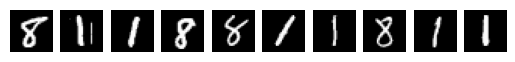

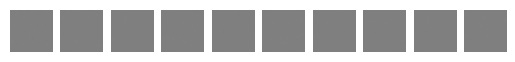

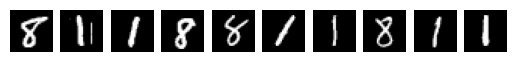

Autoencoder reconstruction error (infinity to 0): 2.137
Counterfactual prediction gain (0 to 1): 0.000
Sparsity (L1, infinity to 0): 0.002


  6%|▌         | 300/5100 [12:33<2:59:17,  2.24s/it]

66/66 [==============================] - 0s 6ms/step
Training iteration 300 at 2025-10-05 09:51:41.426733


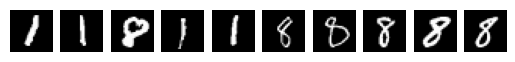

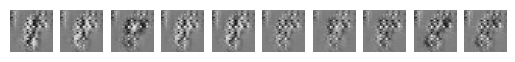

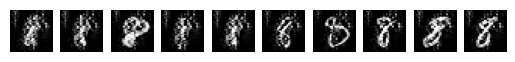

Autoencoder reconstruction error (infinity to 0): 6.562
Counterfactual prediction gain (0 to 1): 0.549
Sparsity (L1, infinity to 0): 0.142


 12%|█▏        | 600/5100 [31:21<9:08:57,  7.32s/it]

66/66 [==============================] - 1s 13ms/step
Training iteration 600 at 2025-10-05 10:10:34.797705


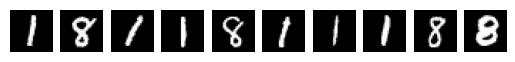

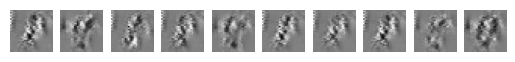

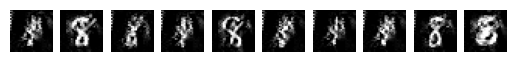

Autoencoder reconstruction error (infinity to 0): 5.453
Counterfactual prediction gain (0 to 1): 0.548
Sparsity (L1, infinity to 0): 0.130


 18%|█▊        | 900/5100 [57:22<3:10:10,  2.72s/it] 

66/66 [==============================] - 0s 5ms/step
Training iteration 900 at 2025-10-05 10:36:29.789673


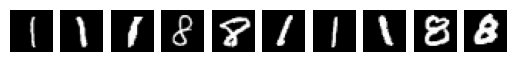

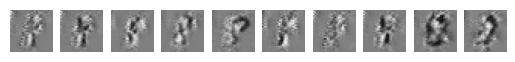

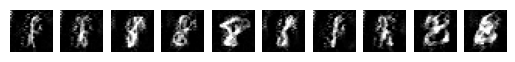

Autoencoder reconstruction error (infinity to 0): 4.697
Counterfactual prediction gain (0 to 1): 0.543
Sparsity (L1, infinity to 0): 0.123


 24%|██▎       | 1200/5100 [1:15:21<4:19:22,  3.99s/it]

66/66 [==============================] - 0s 6ms/step
Training iteration 1200 at 2025-10-05 10:54:29.466238


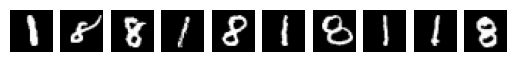

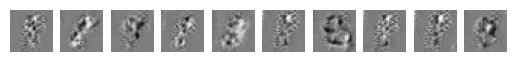

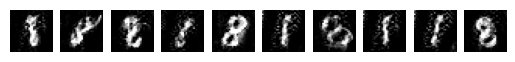

Autoencoder reconstruction error (infinity to 0): 4.288
Counterfactual prediction gain (0 to 1): 0.533
Sparsity (L1, infinity to 0): 0.112


 29%|██▉       | 1500/5100 [1:40:47<3:30:10,  3.50s/it]

66/66 [==============================] - 0s 6ms/step
Training iteration 1500 at 2025-10-05 11:19:55.433483


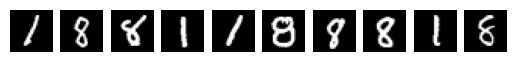

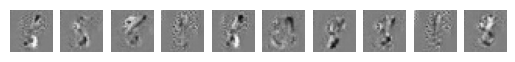

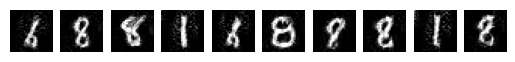

Autoencoder reconstruction error (infinity to 0): 3.588
Counterfactual prediction gain (0 to 1): 0.503
Sparsity (L1, infinity to 0): 0.092


 35%|███▌      | 1800/5100 [2:02:42<4:13:47,  4.61s/it]

66/66 [==============================] - 0s 7ms/step
Training iteration 1800 at 2025-10-05 11:41:51.445832


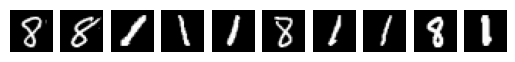

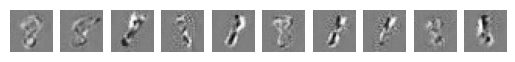

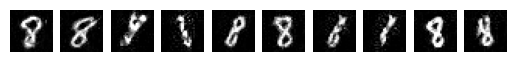

Autoencoder reconstruction error (infinity to 0): 3.444
Counterfactual prediction gain (0 to 1): 0.494
Sparsity (L1, infinity to 0): 0.089


 41%|████      | 2100/5100 [2:25:17<3:54:00,  4.68s/it]

66/66 [==============================] - 0s 7ms/step
Training iteration 2100 at 2025-10-05 12:04:26.786412


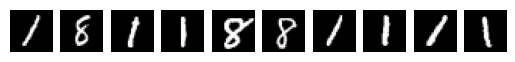

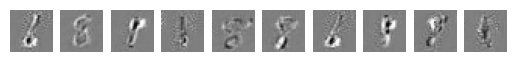

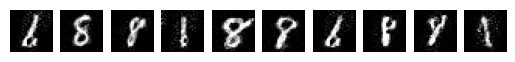

Autoencoder reconstruction error (infinity to 0): 3.282
Counterfactual prediction gain (0 to 1): 0.498
Sparsity (L1, infinity to 0): 0.087


 47%|████▋     | 2400/5100 [3:15:26<8:57:45, 11.95s/it]

66/66 [==============================] - 1s 17ms/step
Training iteration 2400 at 2025-10-05 12:54:41.737230


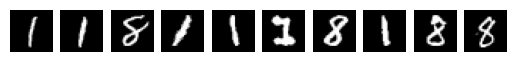

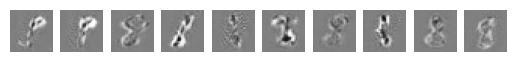

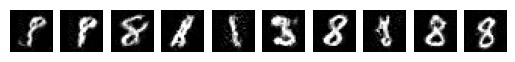

Autoencoder reconstruction error (infinity to 0): 3.257
Counterfactual prediction gain (0 to 1): 0.489
Sparsity (L1, infinity to 0): 0.086


 53%|█████▎    | 2700/5100 [3:42:12<3:20:36,  5.02s/it] 

66/66 [==============================] - 1s 8ms/step
Training iteration 2700 at 2025-10-05 13:21:22.427209


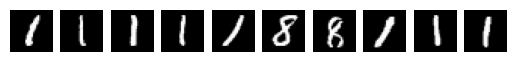

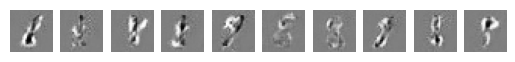

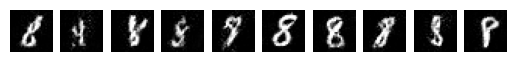

Autoencoder reconstruction error (infinity to 0): 3.185
Counterfactual prediction gain (0 to 1): 0.495
Sparsity (L1, infinity to 0): 0.085


 59%|█████▉    | 3000/5100 [4:26:55<3:04:11,  5.26s/it]

66/66 [==============================] - 0s 7ms/step
Training iteration 3000 at 2025-10-05 14:06:05.305946


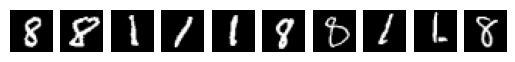

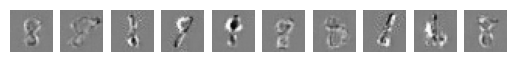

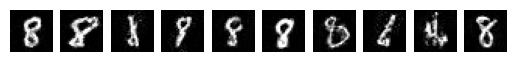

Autoencoder reconstruction error (infinity to 0): 3.077
Counterfactual prediction gain (0 to 1): 0.490
Sparsity (L1, infinity to 0): 0.083


 65%|██████▍   | 3300/5100 [4:56:29<2:46:48,  5.56s/it]

66/66 [==============================] - 1s 8ms/step
Training iteration 3300 at 2025-10-05 14:35:39.603780


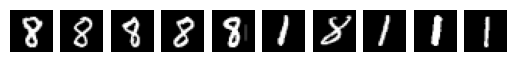

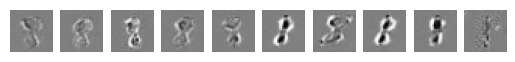

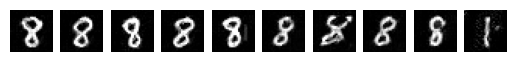

Autoencoder reconstruction error (infinity to 0): 3.073
Counterfactual prediction gain (0 to 1): 0.484
Sparsity (L1, infinity to 0): 0.082


 71%|███████   | 3600/5100 [5:27:30<2:45:00,  6.60s/it]

66/66 [==============================] - 1s 9ms/step
Training iteration 3600 at 2025-10-05 15:06:40.883485


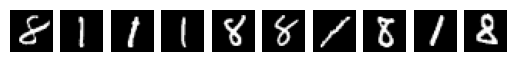

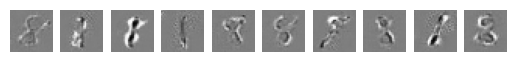

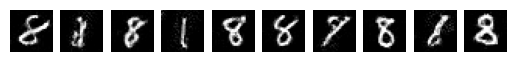

Autoencoder reconstruction error (infinity to 0): 3.040
Counterfactual prediction gain (0 to 1): 0.482
Sparsity (L1, infinity to 0): 0.083


 76%|███████▋  | 3900/5100 [5:58:24<2:04:16,  6.21s/it]

66/66 [==============================] - 1s 8ms/step
Training iteration 3900 at 2025-10-05 15:37:34.705190


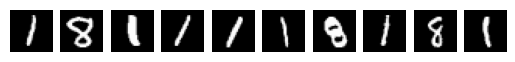

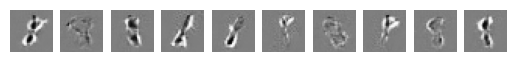

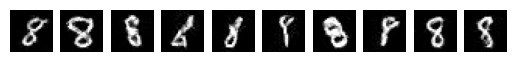

Autoencoder reconstruction error (infinity to 0): 2.918
Counterfactual prediction gain (0 to 1): 0.484
Sparsity (L1, infinity to 0): 0.078


 82%|████████▏ | 4200/5100 [6:31:00<1:37:51,  6.52s/it]

66/66 [==============================] - 1s 11ms/step
Training iteration 4200 at 2025-10-05 16:10:10.837914


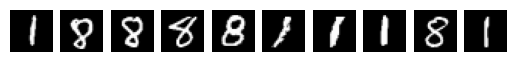

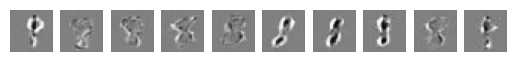

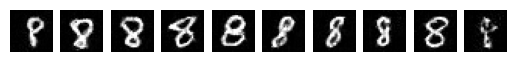

Autoencoder reconstruction error (infinity to 0): 3.065
Counterfactual prediction gain (0 to 1): 0.493
Sparsity (L1, infinity to 0): 0.086


 88%|████████▊ | 4500/5100 [7:05:50<1:07:04,  6.71s/it]

66/66 [==============================] - 1s 9ms/step
Training iteration 4500 at 2025-10-05 16:45:01.385112


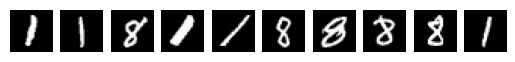

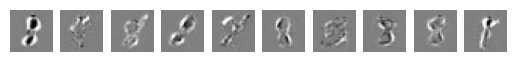

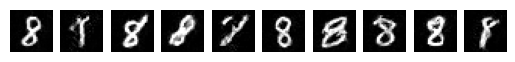

Autoencoder reconstruction error (infinity to 0): 3.043
Counterfactual prediction gain (0 to 1): 0.496
Sparsity (L1, infinity to 0): 0.089


 94%|█████████▍| 4800/5100 [8:23:36<1:29:17, 17.86s/it]

66/66 [==============================] - 2s 31ms/step
Training iteration 4800 at 2025-10-05 18:02:59.993456


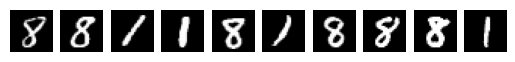

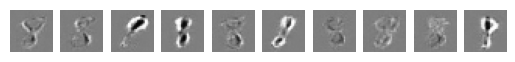

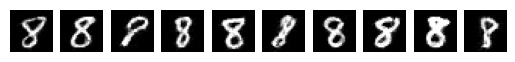

Autoencoder reconstruction error (infinity to 0): 2.952
Counterfactual prediction gain (0 to 1): 0.495
Sparsity (L1, infinity to 0): 0.086


100%|█████████▉| 5099/5100 [9:14:51<00:08,  8.44s/it]  

66/66 [==============================] - 1s 11ms/step
Training iteration 5099 at 2025-10-05 18:54:03.598016


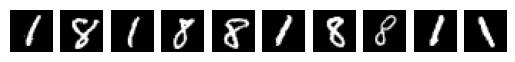

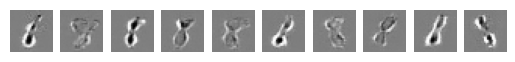

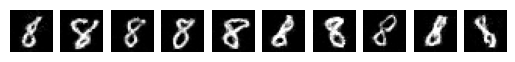

Autoencoder reconstruction error (infinity to 0): 2.953
Counterfactual prediction gain (0 to 1): 0.491
Sparsity (L1, infinity to 0): 0.086


100%|██████████| 5100/5100 [9:15:10<00:00,  6.53s/it]


In [37]:
method_name = "countergan"
countergan = train_countergan(2, 3, 5100, baseline_classifier, discriminator, generator, batches)

# Evaluation of CounterGAN

Load perts of CounteRGAN

In [181]:
models_save_dir = r'D:\PycharmProjects\CF-Robustness-Benchmark\cf_output\mnist\countergan_binary\checkpoints_1_8_trial2'

generator_fname = 'generator_1_8_iter_5099.keras' 
# generator_fname = 'generator_1_7_iter_5100.keras'
discriminator_fname = 'discriminator_1_8_iter_5099.keras' 
# discriminator_fname = 'discriminator_1_7_iter_5100.keras'


generator = load_model(osp.join(models_save_dir, generator_fname))
discriminator = load_model(osp.join(models_save_dir, discriminator_fname))

In [182]:
class_ind = np.where(y_test == class_encodings[INIT_CLASS])[0]
factuals = X_test[class_ind]
labels =  y_test[class_ind]

print('Total number of factual instances: ', factuals.shape[0])

Total number of factual instances:  1135


In [183]:
predictions = tf.argmax(baseline_classifier.predict(factuals, verbose=0), axis=1)
_, valid_indices = np.where([predictions == tf.argmax(labels, axis=1)])
factuals = tf.gather(factuals, valid_indices)
labels = tf.gather(labels, valid_indices) 

## Robustness Evaluation

### Local Instability

In [184]:
from functools import reduce
from src.evaluation.local_instability import perturb_sample
from src.evaluation.local_instability import calculate_sparsity, calculate_ssim
from src.utils.visualization import plot_boxplot

In [185]:
cfes = generator.predict(factuals, verbose=0)

In [186]:
noise_levels = [0.005, 0.01, 0.015, 0.02, 0.025]

In [187]:
factuals_pert = {}
pert_indices = {}

for noise_level in noise_levels:
    pert_sample = perturb_sample(factuals, n_samples=1, epsilon=noise_level, 
                                 type='uniform', channels_first=False) 
    pert_sample = pert_sample.squeeze(1)
    factuals_pert[noise_level] = pert_sample

    # Check whether perturbed instances lead to the same class prediction
    predictions = tf.argmax(baseline_classifier.predict(pert_sample, verbose=0), axis=1)
   
    # targets = tf.argmax(labels, axis=1)
    indices = np.where([predictions == labels])[1]
    pert_indices[noise_level] = indices

    print('Number of valid perturbed factuals for the added noise level {}: {}'.format(noise_level, factuals_pert[noise_level].shape[0]))

Number of valid perturbed factuals for the added noise level 0.005: 1134
Number of valid perturbed factuals for the added noise level 0.01: 1134
Number of valid perturbed factuals for the added noise level 0.015: 1134
Number of valid perturbed factuals for the added noise level 0.02: 1134
Number of valid perturbed factuals for the added noise level 0.025: 1134


In [188]:
n = 100
final_indices = reduce(np.intersect1d, list(pert_indices.values()))[:n]
factuals = tf.gather(factuals, final_indices) 
labels = tf.gather(labels, final_indices)

cfes = tf.gather(cfes, final_indices).numpy()
factuals_pert = {k : tf.gather(v, final_indices) for k, v in factuals_pert.items()}
cfes_pert =  {k: generator.predict(v, verbose=0) for k, v in factuals_pert.items()} 

In [189]:
cfes_pred = tf.argmax(baseline_classifier.predict(cfes, verbose=0), axis=1)
validity = np.where(cfes_pred == class_encodings[DESIRED_CLASS])[0].shape[0] / cfes.shape[0]
print(f'Validity of the generated CFEs: {validity:.2%}')

Validity of the generated CFEs: 100.00%


In [150]:
validity_list = []
for noise_level in noise_levels:
    cfes_pert_pred = tf.argmax(baseline_classifier.predict(cfes_pert[noise_level], verbose=0), axis=1)
    validity = len(np.where(cfes_pert_pred == class_encodings[DESIRED_CLASS])[0]) / len(cfes)
    print(f'Validity of the generated CFEs under the noise level {noise_level}: {validity:.2%}')
    
    validity_list.append(validity)

output_dir = r'D:\PycharmProjects\CF-Robustness-Benchmark\cf_output\mnist\countergan_binary'
with open(osp.join(output_dir, f'mnist_{DESIRED_CLASS}_validity.pkl'), 'wb') as f:
    pickle.dump(validity_list, f)

Validity of the generated CFEs under the noise level 0.005: 100.00%
Validity of the generated CFEs under the noise level 0.01: 100.00%
Validity of the generated CFEs under the noise level 0.015: 100.00%
Validity of the generated CFEs under the noise level 0.02: 100.00%
Validity of the generated CFEs under the noise level 0.025: 100.00%


In [151]:
# Check for the bounded noise

for noise_level in noise_levels:
    # diffs = np.abs(factuals - factuals_pert[noise_level])
    diffs = np.linalg.norm((factuals - factuals_pert[noise_level]).reshape(-1, 1), ord=np.Inf)
    print('Maximum difference between original and perturbed factuals for the noise level {:.2f}: {}'.format(noise_level, diffs))

Maximum difference between original and perturbed factuals for the noise level 0.01: 0.004999879228452131
Maximum difference between original and perturbed factuals for the noise level 0.01: 0.009999704707914133
Maximum difference between original and perturbed factuals for the noise level 0.01: 0.014999932446803563
Maximum difference between original and perturbed factuals for the noise level 0.02: 0.019999536952567277
Maximum difference between original and perturbed factuals for the noise level 0.03: 0.024999905005934665


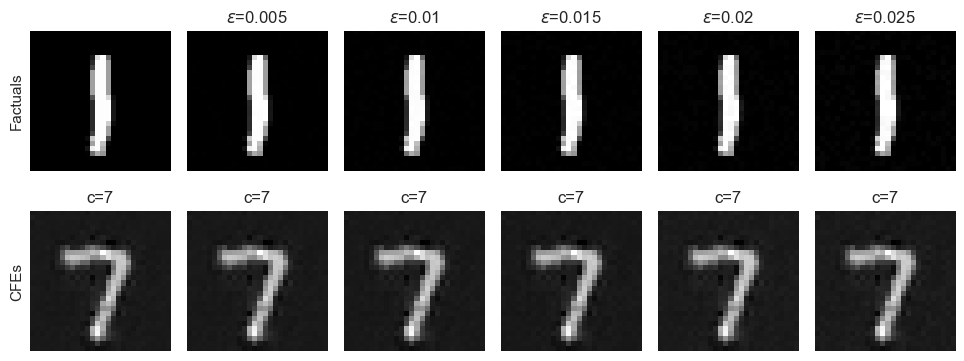

In [153]:
plt.style.use("seaborn-v0_8")

ind = 10
factuals_pert_list = [factuals_pert[noise_level][ind] for noise_level in noise_levels]
cfes_pert_list = [cfes_pert[noise_level][ind] for noise_level in noise_levels]

factuals_vis = [factuals[ind]] + factuals_pert_list
cfes_vis = [cfes[ind]] + cfes_pert_list

n_rows = 2
n_cols = len(factuals_vis)

_, axs = plt.subplots(n_rows, n_cols, figsize=(10, 4), sharex=True, sharey=True)
for j in range(n_cols):
    axs[0, j].imshow(factuals_vis[j] , cmap="gray")
    if noise_levels and j > 0:
        noise = noise_levels[j-1]
        axs[0, j].set_title("$\\epsilon$={}".format(noise))

    axs[1, j].imshow(cfes_vis[j], cmap="gray")
    pred = tf.argmax(baseline_classifier.predict(tf.expand_dims(cfes_vis[j], axis=0), verbose=0), axis=1).numpy()
    axs[1, j].set_title(f'c={DESIRED_CLASS if pred == class_encodings[DESIRED_CLASS] else class_encodings[INIT_CLASS]}')
    
    if j == 0:
        axs[0, j].set_ylabel('Factuals')
        axs[1, j].set_ylabel('CFEs')

plt.tight_layout()
plt.setp(plt.gcf().get_axes(), xticks=[], yticks=[]);
plt.savefig(osp.join(output_dir, f'countergan_binary_{DESIRED_CLASS}_cfes.png'), dpi=300)
plt.show()

In [154]:
# Calculating L1 distance between the explanations of original and perturbed instances
l1_list = []
ssim_list = []


for i, noise_level in tqdm(enumerate(cfes_pert.keys())):
    l1_temp = []
    ssim_temp = []

    cfs_pert = cfes_pert[noise_level]

    for i in range(cfes_pert[noise_level].shape[0]): 

        l1_distance = calculate_sparsity(cfes[i].flatten(), cfes_pert[noise_level][i].flatten()).item()
        l1_temp.append(l1_distance)

        ssim = calculate_ssim(torch.Tensor(cfes[i]).permute(2, 0, 1).unsqueeze(0), 
                              torch.Tensor(cfes_pert[noise_level][i]).permute(2, 0, 1).unsqueeze(0)).item()
        ssim_temp.append(ssim)

    print(f'Average Instability (L1) for the set of counterfactuals of size : {np.mean(l1_temp)}')    
    l1_list.append(l1_temp)
    
    print(f'Average SSIM for the set of counterfactuals of size : {np.mean(ssim_temp)}')    
    ssim_list.append(ssim_temp)

2it [00:00,  7.11it/s]

Average Instability (L1) for the set of counterfactuals of size : 1.2057805931568146
Average SSIM for the set of counterfactuals of size : 0.9993994474411011
Average Instability (L1) for the set of counterfactuals of size : 2.4110930156707764
Average SSIM for the set of counterfactuals of size : 0.9975981074571609


4it [00:00,  7.17it/s]

Average Instability (L1) for the set of counterfactuals of size : 3.6068562054634095
Average SSIM for the set of counterfactuals of size : 0.9945695346593857
Average Instability (L1) for the set of counterfactuals of size : 4.8293296289443965
Average SSIM for the set of counterfactuals of size : 0.9902351415157318


5it [00:00,  6.89it/s]

Average Instability (L1) for the set of counterfactuals of size : 6.0314359998703
Average SSIM for the set of counterfactuals of size : 0.9849858069419861


In [155]:
with open(osp.join(output_dir, f'mnist_{DESIRED_CLASS}_li_l1.pkl'), 'wb') as f:
    pickle.dump(l1_list, f)

with open(osp.join(output_dir, f'mnist_{DESIRED_CLASS}_ssim.pkl'), 'wb') as f:
    pickle.dump(ssim_list, f)

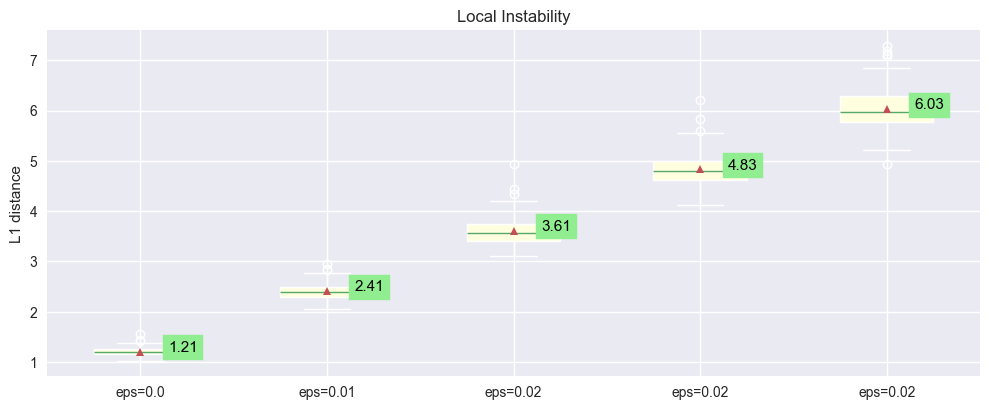

In [156]:
plt.style.use("seaborn-v0_8")

plt.rcParams['figure.figsize'] = [10, 4]

plot_boxplot(data=l1_list, mean_values=[np.round(np.mean(inst),2) for inst in l1_list],
             tick_labels=[f'eps={np.round(noise_level, 2)}' for noise_level in noise_levels],
             y_label='L1 distance', colors=['lightyellow'], title='Local Instability')

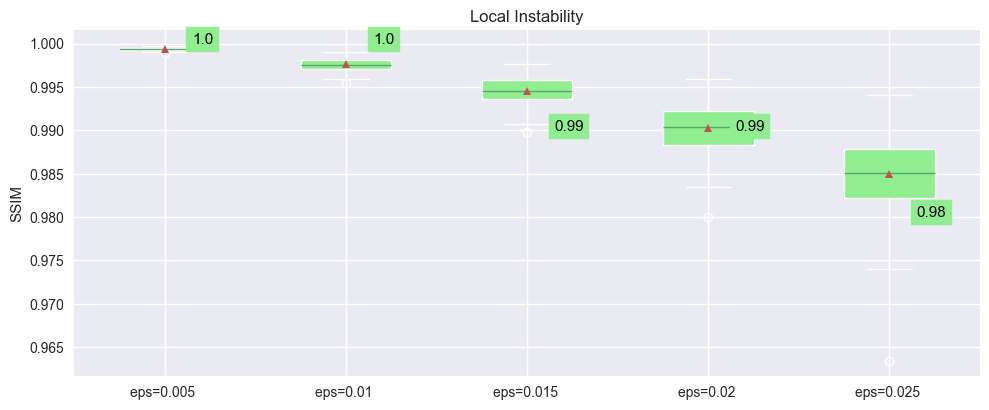

In [157]:
plot_boxplot(data=ssim_list, mean_values=[np.round(np.mean(inst),2) for inst in ssim_list],
             tick_labels=[f'eps={noise_level} ' for noise_level in noise_levels],
             y_label='SSIM', colors=['lightgreen'], title='Local Instability')

### Local Lipschitz Continuity

In [158]:
original_points = factuals
original_cfes = cfes
print("Are the lengths of initial points (factuals) and CFEs generated for them equal :", original_cfes.shape[0] == original_points.shape[0])

Are the lengths of initial points (factuals) and CFEs generated for them equal : True


In [159]:
noise_magnitude = 0.01

lip_estimates = []
n_samples = 30

for original_point, original_cfe in tqdm(zip(original_points[:30], original_cfes[:30])):

    neighbor_points = perturb_sample(original_point, n_samples=n_samples, 
                                     epsilon=noise_magnitude, type='uniform', 
                                     channels_first=False) 
    neighbor_points = neighbor_points.squeeze(0)
    neighbor_cfes = generator.predict(neighbor_points, verbose=False)

    lip_estimate = 0
    for m, p in zip(neighbor_cfes, neighbor_points):
        num = np.linalg.norm((original_cfe - m).flatten(), ord=2) 
        denom = np.linalg.norm((original_point.numpy() - p).flatten(), ord=2)
        lip = num / denom
        lip_estimate = max(lip, lip_estimate)
 
    lip_estimates.append(lip_estimate)


30it [00:02, 10.69it/s]


In [160]:
with open(osp.join(output_dir, f'mnist_{DESIRED_CLASS}_lle.pkl'), 'wb') as f:
    pickle.dump(lip_estimates, f)

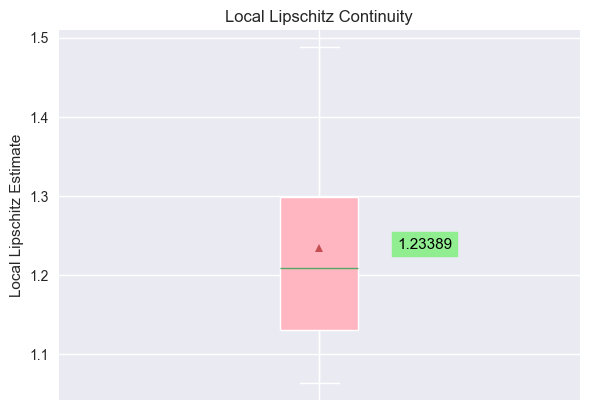

In [161]:
plt.rcParams['figure.figsize'] = [6, 4]
plot_boxplot(data=lip_estimates, mean_values=[np.round(np.mean(lip_estimates), 5)],
             tick_labels=[''],
             y_label='Local Lipschitz Estimate', colors=['lightpink'], title='Local Lipschitz Continuity')

### Invalidation Rate

Weights reinitialization

In [190]:
classifiers_weights_dir = r'D:\PycharmProjects\CF-Robustness-Benchmark\notebooks\experiments\mnist_classification\binary\checkpoints\mc_1_8_tf'
classifiers_list = []
for clf_fname in os.listdir(classifiers_weights_dir):
    cnn_perturbed = load_model(osp.join(classifiers_weights_dir, clf_fname), 
                            custom_objects={'CNNtf': CNNtf})
    classifiers_list.append(cnn_perturbed)

    logits = cnn_perturbed.predict(X_test)
    accuracy = (logits.argmax(axis=1) == y_test[:, 0]).numpy().mean()
    print(f"Classifier accuracy test: {accuracy:.3%}")

66/66 [==============================] - 1s 17ms/step
Classifier accuracy test: 99.953%
66/66 [==============================] - 1s 10ms/step
Classifier accuracy test: 99.478%
66/66 [==============================] - 1s 9ms/step
Classifier accuracy test: 99.953%
66/66 [==============================] - 1s 9ms/step
Classifier accuracy test: 99.953%
66/66 [==============================] - 1s 8ms/step
Classifier accuracy test: 100.000%
66/66 [==============================] - 1s 7ms/step
Classifier accuracy test: 100.000%
66/66 [==============================] - 0s 6ms/step
Classifier accuracy test: 100.000%
66/66 [==============================] - 1s 9ms/step
Classifier accuracy test: 99.953%
66/66 [==============================] - 1s 8ms/step
Classifier accuracy test: 99.953%
66/66 [==============================] - 1s 7ms/step
Classifier accuracy test: 99.953%


Evaluate IR only for the valid explanations for the baseline classifier

In [191]:
predictions = tf.argmax(baseline_classifier.predict(cfes, verbose=0), axis=1)
indices = np.where(predictions == class_encodings[DESIRED_CLASS])[0]
cfes_subsample = tf.gather(cfes, indices)
cfes_subsample.shape

validity = len(np.where(predictions == class_encodings[DESIRED_CLASS])[0]) / len(cfes)
print(f'Validity of the generated CFEs for correctly classified instances: {validity:.2%}')

Validity of the generated CFEs for correctly classified instances: 100.00%


In [192]:
invalidation_rate_list = []
validity_list = []
total_cfs = cfes_subsample.shape[0]


for i, classifier in enumerate(classifiers_list):
    invalidation_rate = 0

    baseline_pred = tf.argmax(baseline_classifier.predict(cfes_subsample, verbose=0), axis=1)
    alternative_pred = tf.argmax(classifier.predict(cfes_subsample, verbose=0), axis=1)

    invalidation_rate_list.append(baseline_pred != alternative_pred)

inv_rate_array = np.asarray(invalidation_rate_list)
inv_rate_avg = inv_rate_array.mean(axis=0)
var_avg = 1 - inv_rate_avg
print("Average IR of the sample among {} models: {:.3f} ({:.3f})".format(len(classifiers_list), inv_rate_avg.mean(), inv_rate_avg.std()))
print("Average VaR of the sample among {} models: {:.3f} ({:.3f})".format(len(classifiers_list), var_avg.mean(), var_avg.std()))

Average IR of the sample among 10 models: 0.240 (0.362)
Average VaR of the sample among 10 models: 0.760 (0.362)


### Stability 

In [193]:
k = 1000
average_stability_list = []


for i, classifier in enumerate(classifiers_list):
    stability_list = []
    stability = 0

    original_logits = classifier.predict(cfes_subsample, verbose=0)
    # To calculate stability of only valid CFE, they need to be identified
    valid_cfs_ind = tf.where(original_logits.argmax(axis=1) == class_encodings[DESIRED_CLASS])[:, 0]
    print('Number of valid CFEs for the model {}: {}'.format(i, valid_cfs_ind.shape[0]))
    original_logits_subsample = tf.gather(original_logits, valid_cfs_ind)

    original_probabilities = tf.nn.softmax(original_logits_subsample, axis=-1)[:, class_encodings[DESIRED_CLASS]]

    valid_cfs_subsample = tf.gather(cfes_subsample, valid_cfs_ind)
    cf_sample_pert = perturb_sample(valid_cfs_subsample, n_samples=k, 
                                    type='normal', epsilon=0, std=0.01)

    for j in range(original_probabilities.shape[0]):
        cf_sample_pert_j = cf_sample_pert[j] 
        logits = classifier.predict(cf_sample_pert_j, verbose=0)
        probabilities = tf.nn.softmax(logits, axis=-1)[:, class_encodings[DESIRED_CLASS]]

        original_probabilities_i = tf.expand_dims(original_probabilities[j], axis=-1)
        model_variance = abs(original_probabilities_i - probabilities)
        stability = (probabilities - model_variance).numpy().mean()
    
        stability_list.append(stability)

    avg_i_stability = np.mean(stability_list)
    print(f'Average Stability of the model {i}: {round(avg_i_stability.item(), 3)} +- {round(np.std(stability_list).item(), 2)}')
    average_stability_list.append(avg_i_stability)

Number of valid CFEs for the model 0: 83
Average Stability of the model 0: 0.669 +- 0.08
Number of valid CFEs for the model 1: 60
Average Stability of the model 1: 0.635 +- 0.09
Number of valid CFEs for the model 2: 77
Average Stability of the model 2: 0.641 +- 0.1
Number of valid CFEs for the model 3: 74
Average Stability of the model 3: 0.663 +- 0.1
Number of valid CFEs for the model 4: 80
Average Stability of the model 4: 0.653 +- 0.09
Number of valid CFEs for the model 5: 81
Average Stability of the model 5: 0.666 +- 0.1
Number of valid CFEs for the model 6: 80
Average Stability of the model 6: 0.673 +- 0.08
Number of valid CFEs for the model 7: 80
Average Stability of the model 7: 0.657 +- 0.1
Number of valid CFEs for the model 8: 72
Average Stability of the model 8: 0.669 +- 0.08
Number of valid CFEs for the model 9: 73
Average Stability of the model 9: 0.671 +- 0.07


In [194]:
print(f"Average stability : {round(np.mean(average_stability_list).item(), 3)} +- {round(np.std(average_stability_list).item(), 3)}")

Average stability : 0.66 +- 0.012


### LOF

In [195]:
from sklearn.neighbors import LocalOutlierFactor

In [196]:
target_class_set = X_test[np.where(y_test==class_encodings[DESIRED_CLASS])[0]]
target_class_set.shape

TensorShape([974, 28, 28, 1])

In [197]:
lof = LocalOutlierFactor(n_neighbors=5, novelty=True, p=1)
lof.fit(target_class_set.reshape(target_class_set.shape[0], -1))

target_class_ascores = lof.score_samples(cfes.reshape(cfes.shape[0], -1))
target_class_classes = np.where(target_class_ascores < -1.1, -1, 1)
print('Average negative LOF (the lower values the more anomaluous): {:.3f} +- {:.3f}'.format(np.mean(target_class_ascores), 
                                                                                            np.std(target_class_ascores)))

Average negative LOF (the lower values the more anomaluous): -1.354 +- 0.181


In [198]:
lof = LocalOutlierFactor(n_neighbors=5, novelty=True, p=1)
lof.fit(X_test.reshape(X_test.shape[0], -1))

ascores = lof.score_samples(cfes.reshape(cfes.shape[0], -1))
aclasses = np.where(target_class_ascores < -1.2, -1, 1)
print('Average negative LOF (the lower values the more anomaluous): {:.3f} +- {:.3f}'.format(np.mean(ascores), np.std(ascores)))

Average negative LOF (the lower values the more anomaluous): -2.645 +- 1.388
